### Part 5: Statistical Edge 

In [75]:
# numerical computing library for fast calculation
import numpy as np
# data analysis library
import pandas as pd
# data visualization library
import seaborn as sns

# machine learning library
import torch
import torch.nn as nn
import torch.optim as optim

### Matrix Algebra

What is a Matrix

In [76]:
matrix = [[1,2,3], [4,5,6],[7,8,9]]

In [77]:
matrix[0]

[1, 2, 3]

In [78]:
matrix[0][0]

1

In [79]:
matrix[0][1]

2

In [80]:
matrix[0][2]

3

In [81]:
matrix[1][0]

4

### Matrix Scalar Algebra

In [82]:
no_rows = len(matrix)
no_cols = len(matrix[0])

m = no_rows
n = no_cols

for i in range(m):
    for j in range(n):
        matrix[i][j] += 1
matrix

[[2, 3, 4], [5, 6, 7], [8, 9, 10]]

In [83]:
[
    [1 + 1, 2 + 1, 3 + 1],
    [4 + 1, 5 + 1, 6 + 1],
    [7 + 1, 8 + 1, 9 + 1],
]

[[2, 3, 4], [5, 6, 7], [8, 9, 10]]

In [84]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])

A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [85]:
A + 1

array([[ 2,  3,  4],
       [ 5,  6,  7],
       [ 8,  9, 10]])

In [86]:
1 + A

array([[ 2,  3,  4],
       [ 5,  6,  7],
       [ 8,  9, 10]])

In [87]:
A * 2

array([[ 2,  4,  6],
       [ 8, 10, 12],
       [14, 16, 18]])

### Matrix-Vector Algebra

X * w = y_hat

In [88]:
X = np.array([[-0.1,-0.2], [-0.2, -0.4], [-0.4, -0.8]])

X

array([[-0.1, -0.2],
       [-0.2, -0.4],
       [-0.4, -0.8]])

In [89]:
w = np.array([-0.5, -0.1])
w

array([-0.5, -0.1])

In [90]:
np.dot(X, w)

array([0.07, 0.14, 0.28])

In [91]:
w1 = w[0]
w2 = w[1]

np.array([-0.1 * w1 + -0.2 * w2,-0.2 * w1 + -0.4 * w2,-0.4 * w1 + -0.8 * w2])

array([0.07, 0.14, 0.28])

In [92]:
bias = 0.0001
b = bias

In [93]:
np.dot(X,w) + b

array([0.0701, 0.1401, 0.2801])

Broadcasting does not equal Matrix Multiplication

In [94]:
X * w

array([[0.05, 0.02],
       [0.1 , 0.04],
       [0.2 , 0.08]])

In [95]:
np.dot(X,w)

array([0.07, 0.14, 0.28])

How to devlop a Statistical Edge using Machine Learning

### Statistical Edge == Good Forecast

### Download OHLC perp data

In [96]:
import pandas as pd

btcusdt = pd.read_csv(
    "../data/BTCUSDT-1h.csv",
    parse_dates=["open_time"],
    index_col="open_time"
)

btcusdt

,open,high,low,close,volume
open_time,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299
...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325


In [97]:
btcusdt['close_log_return'] = np.log(btcusdt['close']/btcusdt['close'].shift())
btcusdt

,open,high,low,close,volume,close_log_return
open_time,,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474,NaN
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689,-0.005189
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837,-0.012063
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593,-0.001072
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-0.000263
...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,0.003138
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,0.001790
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,-0.003528


In [98]:
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()
btcusdt['close_log_return_lag_2'] = btcusdt['close_log_return'].shift(2)
btcusdt['close_log_return_lag_3'] = btcusdt['close_log_return'].shift(3)
btcusdt = btcusdt.dropna()
btcusdt[['close_log_return','close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']]

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,
2020-11-27 04:00:00,-0.000263,-0.001072,-0.012063,-0.005189
2020-11-27 05:00:00,0.010946,-0.000263,-0.001072,-0.012063
2020-11-27 06:00:00,0.001109,0.010946,-0.000263,-0.001072
2020-11-27 07:00:00,-0.010552,0.001109,0.010946,-0.000263
2020-11-27 08:00:00,-0.014575,-0.010552,0.001109,0.010946
...,...,...,...,...
2025-11-10 19:00:00,0.003138,-0.004455,0.006797,0.001525
2025-11-10 20:00:00,0.001790,0.003138,-0.004455,0.006797
2025-11-10 21:00:00,-0.003528,0.001790,0.003138,-0.004455


In [99]:
btcusdt[['close_log_return','close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']].corr()

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
close_log_return,1.000000,-0.005855,-0.012630,-0.001328
close_log_return_lag_1,-0.005855,1.000000,-0.005846,-0.012627
close_log_return_lag_2,-0.012630,-0.005846,1.000000,-0.005803
close_log_return_lag_3,-0.001328,-0.012627,-0.005803,1.000000


### Inspect the data

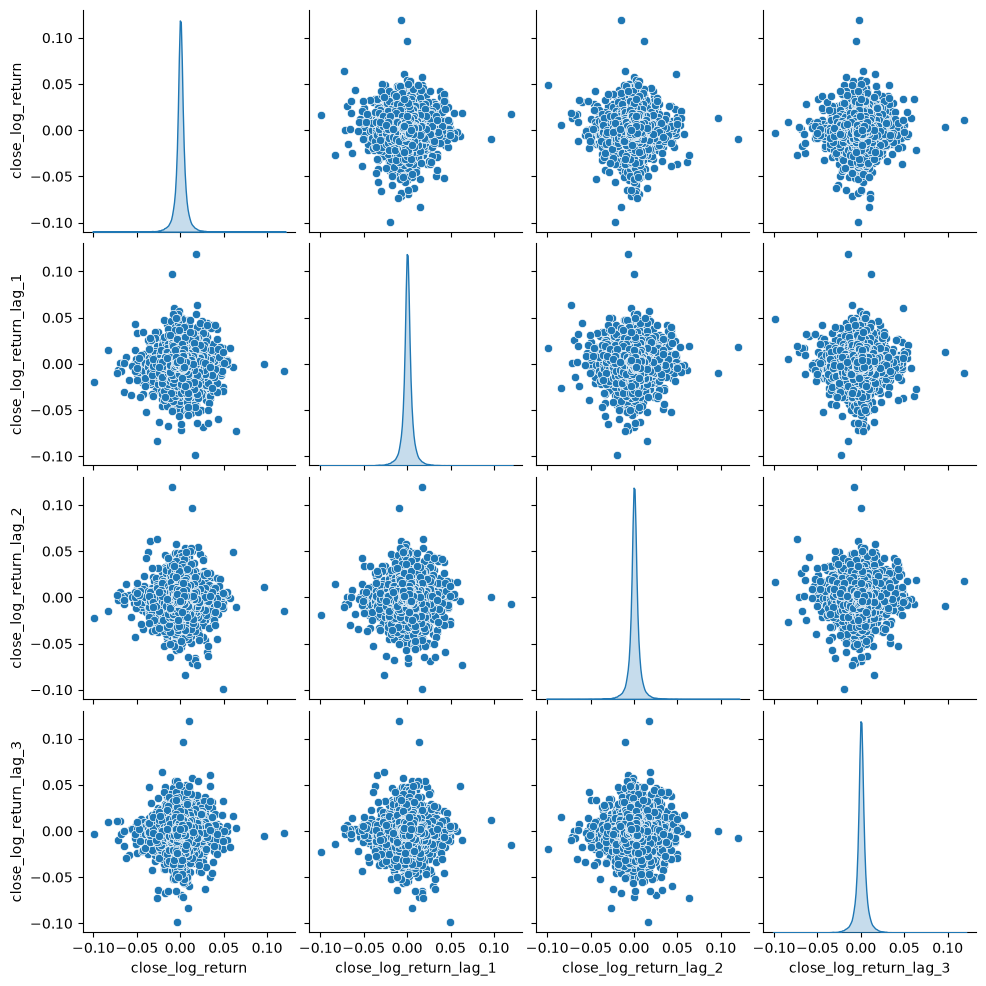

In [100]:
sns.pairplot(btcusdt[['close_log_return','close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']], diag_kind="kde")

In [101]:
X = btcusdt[['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']].dropna().values
X

array([[-0.00107236, -0.01206327, -0.0051893 ],
       [-0.00026285, -0.00107236, -0.01206327],
       [ 0.01094601, -0.00026285, -0.00107236],
       ...,
       [ 0.00179007,  0.00313822, -0.00445534],
       [-0.00352841,  0.00179007,  0.00313822],
       [ 0.00397283, -0.00352841,  0.00179007]], shape=(43436, 3))

In [102]:
X.shape

(43436, 3)

In [103]:
y = btcusdt['close_log_return'].dropna().values
y

array([-0.00026285,  0.01094601,  0.00110898, ..., -0.00352841,
        0.00397283, -0.00035382], shape=(43436,))

In [104]:
y.shape

(43436,)

Forecasting: Regression

### Split Training/Testing Data

In [105]:
# time:  t0 ---- t1 ---- t2 ---- t3 ---- t4 ---- t5 ---- t6 ---- t7
# train: [===============================]
# test:                                  [=========================]

In [106]:
def time_split(x, train_size = 0.75):
  i = int(len(x) * train_size)
  return x[:i].copy(), x[i:].copy()

btcusdt_train, btcusdt_test = time_split(btcusdt, train_size = 0.7)

btcusdt_test

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,,,,,,
2024-05-17 01:00:00,65477.9,65478.0,65061.2,65311.0,6160.987,-0.002554,0.003983,-0.002626,-0.000610
2024-05-17 02:00:00,65311.1,65430.0,65146.5,65351.5,4190.566,0.000620,-0.002554,0.003983,-0.002626
2024-05-17 03:00:00,65351.4,65850.0,65300.3,65545.2,11900.518,0.002960,0.000620,-0.002554,0.003983
2024-05-17 04:00:00,65545.1,65600.0,65327.7,65422.7,5906.313,-0.001871,0.002960,0.000620,-0.002554
2024-05-17 05:00:00,65422.8,65675.0,65400.0,65674.9,4946.005,0.003848,-0.001871,0.002960,0.000620
...,...,...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.9,106000.0,105354.0,105767.2,2971.178,0.003138,-0.004455,0.006797,0.001525
2025-11-10 20:00:00,105767.1,106249.6,105750.3,105956.7,3483.547,0.001790,0.003138,-0.004455,0.006797
2025-11-10 21:00:00,105956.7,105973.9,105202.7,105583.5,3305.325,-0.003528,0.001790,0.003138,-0.004455


### Train Model

In [107]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os

# -------------------------------------------------------
# 0. REPRODUCIBILITY SETTINGS
# -------------------------------------------------------
SEED = 99

# Ensure Python’s hash-based operations are deterministic
os.environ["PYTHONHASHSEED"] = str(SEED)

# Set seeds for Python's built-in RNG, NumPy, and PyTorch
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)          # For single-GPU setups
torch.cuda.manual_seed_all(SEED)      # For multi-GPU setups


# -------------------------------------------------------
# 1. CREATE TENSORS FROM DATAFRAME **AFTER SETTING SEEDS**
# -------------------------------------------------------

# Input features (model predictors)
features = ['close_log_return_lag_3']

# Target variable (model output)
target = 'close_log_return'

# Convert train/test splits into PyTorch tensors
X_train = torch.tensor(btcusdt_train[features].values, dtype=torch.float32)
X_test  = torch.tensor(btcusdt_test[features].values, dtype=torch.float32)

# Create target tensors and add a column dimension (N → N×1)
y_train = torch.tensor(btcusdt_train[target].values, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(btcusdt_test[target].values, dtype=torch.float32).unsqueeze(1)


# -------------------------------------------------------
# 2. DEFINE MODEL
# -------------------------------------------------------

# Number of input features (1 in this case)
no_features = len(features)

# Simple linear regression model: y = Wx + b
model = nn.Linear(no_features, 1)

# Huber loss (robust to outliers compared to MSE)
criterion = nn.HuberLoss()

# Stochastic Gradient Descent optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)


# -------------------------------------------------------
# 3. TRAINING LOOP (FULL-BATCH GRADIENT DESCENT)
# -------------------------------------------------------
for epoch in range(5000):

    # Clear previously stored gradients (they accumulate by default)
    optimizer.zero_grad()

    # Forward pass: compute predictions
    y_pred = model(X_train)

    # Compute loss between predictions and true values
    loss = criterion(y_pred, y_train)

    # Backpropagation: compute gradients of loss w.r.t. parameters
    loss.backward()

    # Update model parameters using the computed gradients
    optimizer.step()

    # Print loss every 500 epochs
    if epoch % 500 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())


# -------------------------------------------------------
# 4. CHECK TRAINED PARAMETERS
# -------------------------------------------------------
print("Final weight:", model.weight.data)
print("Final bias:", model.bias.data)


Epoch: 0 Loss: 0.442059189081192
Epoch: 500 Loss: 5.928537939325906e-05
Epoch: 1000 Loss: 4.0195514884544536e-05
Epoch: 1500 Loss: 4.018651452497579e-05
Epoch: 2000 Loss: 4.0178354538511485e-05
Epoch: 2500 Loss: 4.0170187276089564e-05
Epoch: 3000 Loss: 4.016202365164645e-05
Epoch: 3500 Loss: 4.0153863665182143e-05
Epoch: 4000 Loss: 4.014571095467545e-05
Epoch: 4500 Loss: 4.013755460618995e-05
Final weight: tensor([[-0.7914]])
Final bias: tensor([7.8664e-05])


In [108]:
w, b = model.weight, model.bias.item()
print(f"weight = {w}")
print(f"bias = {b}")


weight = Parameter containing:
tensor([[-0.7914]], requires_grad=True)
bias = 7.86635500844568e-05


In [109]:
torch.save(model.state_dict(), "model.pth")

### Evaluate Model (Out of-sample)

In [110]:
y_hat = model(X_test)

y_hat

tensor([[ 0.0006],
        [ 0.0022],
        [-0.0031],
        ...,
        [ 0.0036],
        [-0.0024],
        [-0.0013]], grad_fn=<AddmmBackward0>)

In [111]:
y_hat.detach()

tensor([[ 0.0006],
        [ 0.0022],
        [-0.0031],
        ...,
        [ 0.0036],
        [-0.0024],
        [-0.0013]])

In [112]:
y_hat.detach().shape

torch.Size([13031, 1])

In [113]:
y_hat.detach().squeeze()

tensor([ 0.0006,  0.0022, -0.0031,  ...,  0.0036, -0.0024, -0.0013])

In [114]:
y_hat.detach().squeeze().shape

torch.Size([13031])

In [115]:
btcusdt_test['y_hat'] = y_hat.detach().squeeze()
btcusdt_test[['close_log_return','y_hat']]

,close_log_return,y_hat
open_time,,
2024-05-17 01:00:00,-0.002554,0.000561
2024-05-17 02:00:00,0.000620,0.002157
2024-05-17 03:00:00,0.002960,-0.003074
2024-05-17 04:00:00,-0.001871,0.002100
2024-05-17 05:00:00,0.003848,-0.000412
...,...,...
2025-11-10 19:00:00,0.003138,-0.001128
2025-11-10 20:00:00,0.001790,-0.005300
2025-11-10 21:00:00,-0.003528,0.003604


### Directional Signal

1. 1 = Go Long = Betting price going up
2. -1 = Go Short = Betting price go down

In [116]:
btcusdt_test['dir_signal'] = np.sign(btcusdt_test['y_hat'])


In [117]:
btcusdt_test[['close_log_return', 'y_hat', 'dir_signal']]

,close_log_return,y_hat,dir_signal
open_time,,,
2024-05-17 01:00:00,-0.002554,0.000561,1.0
2024-05-17 02:00:00,0.000620,0.002157,1.0
2024-05-17 03:00:00,0.002960,-0.003074,-1.0
2024-05-17 04:00:00,-0.001871,0.002100,1.0
2024-05-17 05:00:00,0.003848,-0.000412,-1.0
...,...,...,...
2025-11-10 19:00:00,0.003138,-0.001128,-1.0
2025-11-10 20:00:00,0.001790,-0.005300,-1.0
2025-11-10 21:00:00,-0.003528,0.003604,1.0


### Evaluate Directional Accuracy (DA)

In [118]:
btcusdt_test['is_won'] = btcusdt_test['dir_signal'] == np.sign(btcusdt_test[target])

In [119]:
btcusdt_test[['close_log_return','y_hat', 'dir_signal','is_won']]

,close_log_return,y_hat,dir_signal,is_won
open_time,,,,
2024-05-17 01:00:00,-0.002554,0.000561,1.0,False
2024-05-17 02:00:00,0.000620,0.002157,1.0,True
2024-05-17 03:00:00,0.002960,-0.003074,-1.0,False
2024-05-17 04:00:00,-0.001871,0.002100,1.0,False
2024-05-17 05:00:00,0.003848,-0.000412,-1.0,False
...,...,...,...,...
2025-11-10 19:00:00,0.003138,-0.001128,-1.0,False
2025-11-10 20:00:00,0.001790,-0.005300,-1.0,False
2025-11-10 21:00:00,-0.003528,0.003604,1.0,False


In [120]:
da = btcusdt_test['is_won'].mean()
da

np.float64(0.5074821579310874)

### Add Trade Return

In [121]:
btcusdt_test['trade_log_return'] = btcusdt_test['dir_signal'] * btcusdt_test[target]

In [122]:
btcusdt_test[['close_log_return','y_hat', 'dir_signal','is_won', 'trade_log_return']]

,close_log_return,y_hat,dir_signal,is_won,trade_log_return
open_time,,,,,
2024-05-17 01:00:00,-0.002554,0.000561,1.0,False,-0.002554
2024-05-17 02:00:00,0.000620,0.002157,1.0,True,0.000620
2024-05-17 03:00:00,0.002960,-0.003074,-1.0,False,-0.002960
2024-05-17 04:00:00,-0.001871,0.002100,1.0,False,-0.001871
2024-05-17 05:00:00,0.003848,-0.000412,-1.0,False,-0.003848
...,...,...,...,...,...
2025-11-10 19:00:00,0.003138,-0.001128,-1.0,False,-0.003138
2025-11-10 20:00:00,0.001790,-0.005300,-1.0,False,-0.001790
2025-11-10 21:00:00,-0.003528,0.003604,1.0,False,-0.003528


### Evaluate Statistical Edge

In [123]:
btcusdt_test['trade_log_return'].mean()

np.float64(7.944520212342024e-05)

In [124]:
has_statistical_edge = btcusdt_test['trade_log_return'].mean() > 0
has_statistical_edge

np.True_

### Evaluate Total Return

In [125]:
btcusdt_test['trade_log_return'].sum()

np.float64(1.035250428870289)

In [126]:
np.exp(btcusdt_test['trade_log_return'].sum())

np.float64(2.8158113077799216)

In [127]:
initial_capital = 100

np.exp(btcusdt_test['trade_log_return'].sum()) * initial_capital

np.float64(281.58113077799214)

### Evaluate Equity Curve

In [128]:
cum_trade_log_returns = btcusdt_test['trade_log_return'].cumsum()
cum_trade_log_returns

open_time
2024-05-17 01:00:00   -0.002554
2024-05-17 02:00:00   -0.001934
2024-05-17 03:00:00   -0.004893
2024-05-17 04:00:00   -0.006764
2024-05-17 05:00:00   -0.010612
                         ...   
2025-11-10 19:00:00    1.044188
2025-11-10 20:00:00    1.042398
2025-11-10 21:00:00    1.038869
2025-11-10 22:00:00    1.034897
2025-11-10 23:00:00    1.035250
Name: trade_log_return, Length: 13031, dtype: float64

<Axes: xlabel='open_time'>

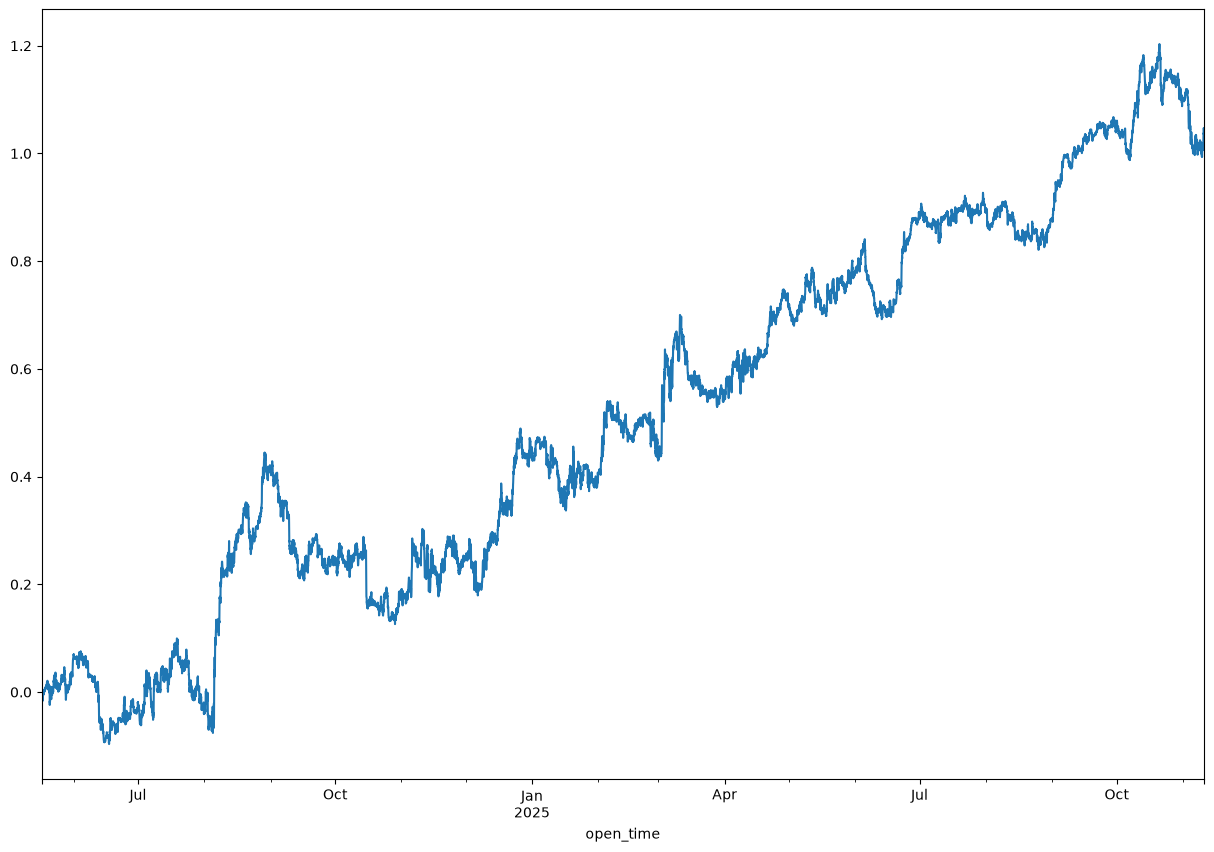

In [129]:
cum_trade_log_returns.plot(figsize=(15,10))

<Axes: xlabel='open_time'>

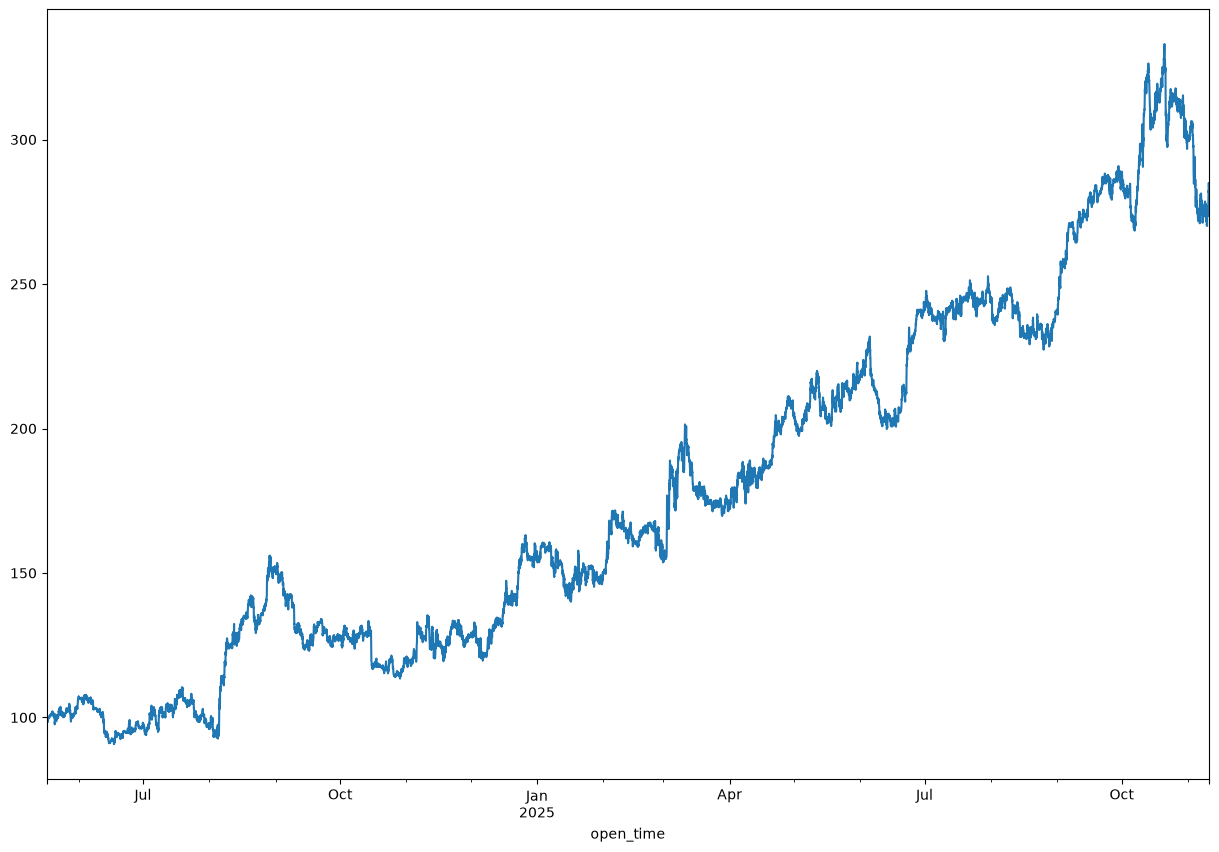

In [130]:
initial_capital = 100
gross_equity_curve = np.exp(cum_trade_log_returns) * 100
gross_equity_curve.plot(figsize=(15,10))

### Evaluate Sharpe Ratio

In [131]:
btcusdt_test['trade_log_return'].mean() / btcusdt_test['trade_log_return'].std()

np.float64(0.015953083956862093)

### Anualization

In [132]:
no_trading_days_in_year = 365
no_hours_in_day = 24
t = no_trading_days_in_year * no_hours_in_day

btcusdt_test['trade_log_return'].mean() / btcusdt_test['trade_log_return'].std() * np.sqrt(t)

np.float64(1.4931268454340678)

### Evaluate Net Returns (inc. Trade Fees)

*   Taker => No Alpha => Fees will decay the edge => Win values reduced => Loss values amplified => Positive EV turns to Negative EV
*   Maker => Alpha => Fees very low and even negative (paid to add liquidity) => Positive EV stays positive

### Exercises

### Exercise 1: Dot Product

In [133]:
X = [
  [-0.1,-0.01],
  [0.2, 0.5]
]
w = [-0.5, -0.25]
y_hat = []


In [134]:
# Manual Loop
for row in X:
    prediction = row[0] * w[0] + row[1] * w[1]
    y_hat.append(prediction)

print(y_hat)

[0.052500000000000005, -0.225]


In [135]:
# write loop to multiply matrix X by vector w and store result in y_hat

y_hat == [-0.1 * -0.5 + -0.01 * -0.25, 0.2 * -0.5 + 0.5 * -0.25]

True

### Exercise 2: Transpose

In [145]:
X = [
  [-0.1,-0.01,-0.2],
  [0.2, 0.5, 0.1]
]
X_transpose = []

In [149]:
# transpose X so you flip the shape from (2,3) to (3, 2)
X_transpose = []

for i in range(len(X[0])):
    row = []
    for j in range(len(X)):
        row.append(X[j][i])
    X_transpose.append(row)
    
print(X_transpose)

[[-0.1, 0.2], [-0.01, 0.5], [-0.2, 0.1]]


In [147]:
X_transpose == [[-0.1, 0.2],[-0.01, 0.5],[-0.2, 0.1]]

True

### Exercise 3: Hadamard Product

In [148]:
y_true = [[0.01, -0.02], [-0.01, -0.03]]
y_hat = [[0.02, -0.03], [0.01, -0.01]]
error = []

In [ ]:
### calc y_true - y_hat = error

error = []

for i in range(len(y_true)):
    row = []
    for j in range(len(y_true[0])):
        row.append(y_true[i][j] - y_hat[i][j])
    error.append(row)

print(error)

[[-0.01, 0.009999999999999998], [-0.02, -0.019999999999999997]]
[[-0.01, 0.009999999999999998], [-0.02, -0.019999999999999997]]


In [151]:
error == [[0.01 - 0.02, -0.02 - (-0.03)],[-0.01 - 0.01, -0.03 - (-0.01)]]

True